In [2]:
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench import (Model, RealParameter, TimeSeriesOutcome,
                           perform_experiments, ema_logging,Policy)

from ema_workbench import Samplers

from ema_workbench.analysis import feature_scoring
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from SALib.analyze import sobol
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from openpyxl.styles.builtins import output
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(3)

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


In [3]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)


CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [4]:
problem = get_SALib_problem(uncertainties)
print(problem)

{'num_vars': 19, 'names': ['A.0_ID flood wave shape', 'A.1_Bmax', 'A.1_Brate', 'A.1_pfail', 'A.2_Bmax', 'A.2_Brate', 'A.2_pfail', 'A.3_Bmax', 'A.3_Brate', 'A.3_pfail', 'A.4_Bmax', 'A.4_Brate', 'A.4_pfail', 'A.5_Bmax', 'A.5_Brate', 'A.5_pfail', 'discount rate 0', 'discount rate 1', 'discount rate 2'], 'bounds': [(0, 133), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (0, 4), (0, 4), (0, 4)]}


In [5]:
print(problem)


def get_do_nothing_dict():
    return {l.name: 0 for l in dike_model.levers}


from ema_workbench import Policy

donothing = Policy('do_nothing', **get_do_nothing_dict())

{'num_vars': 19, 'names': ['A.0_ID flood wave shape', 'A.1_Bmax', 'A.1_Brate', 'A.1_pfail', 'A.2_Bmax', 'A.2_Brate', 'A.2_pfail', 'A.3_Bmax', 'A.3_Brate', 'A.3_pfail', 'A.4_Bmax', 'A.4_Brate', 'A.4_pfail', 'A.5_Bmax', 'A.5_Brate', 'A.5_pfail', 'discount rate 0', 'discount rate 1', 'discount rate 2'], 'bounds': [(0, 133), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (30, 350), (0, 3), (0, 1), (0, 4), (0, 4), (0, 4)]}


In [6]:
n_exp = 1
with MultiprocessingEvaluator(dike_model) as evaluator:
    experiments_sobol, outcomes_sobol = evaluator.perform_experiments(scenarios=n_exp, policies=donothing, uncertainty_sampling=Samplers.SOBOL)

[MainProcess/INFO] pool started with 12 workers
[MainProcess/INFO] performing 40 scenarios * 1 policies * 1 model(s) = 40 experiments
100%|██████████████████████████████████████████| 40/40 [00:03<00:00, 10.44it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [7]:
outcomes_sobol

{'A.1 Total Costs': array([1.32083700e+09, 1.33168332e+09, 1.32083700e+09, 1.32083700e+09,
        0.00000000e+00, 1.32083700e+09, 1.32083700e+09, 1.32083700e+09,
        1.32083700e+09, 1.32083700e+09, 1.32083700e+09, 1.32083700e+09,
        1.32083700e+09, 1.32083700e+09, 1.32083700e+09, 1.32083700e+09,
        1.32083700e+09, 1.23131171e+09, 1.16812691e+09, 1.32083700e+09,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.08745878e+09,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 'A.1_Expected Number of Deaths': array([0.861943  , 0.87067327, 0.861943  , 0.861943  , 0.        ,
        0.861943  , 0.861943  , 0.861943  , 0.861943  , 0.861943  ,
        0.861943  , 0.861943  , 0.861943  , 0.861943  , 0.861943  ,
        0.861943  , 0.

In [8]:
outcomes_sobol['A.5_Expected Number of Deaths']

array([0.        , 0.        , 0.        , 0.        , 0.02862747,
       0.        , 0.        , 0.        , 0.00938974, 0.        ,
       0.11509491, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.39960059, 0.46890726, 0.46890726, 0.02259605, 0.46929055,
       0.46890726, 0.47372777, 0.46890726, 0.46890726, 0.        ,
       0.46890726, 0.46890726, 0.47670081, 0.46890726, 0.46890726,
       0.59001325, 0.46890726, 0.46890726, 0.46890726, 0.46890726])

In [16]:
A5_deaths_final_sobol = outcomes_sobol['A.5_Expected Number of Deaths']

Si = sobol.analyze(problem, A5_deaths_final_sobol, calc_second_order=True, print_to_console=True)

                               ST       ST_conf
A.0_ID flood wave shape  0.000000  0.000000e+00
A.1_Bmax                 0.000000  0.000000e+00
A.1_Brate                0.000000  0.000000e+00
A.1_pfail                0.007455  1.708562e-18
A.2_Bmax                 0.000000  0.000000e+00
A.2_Brate                0.000000  0.000000e+00
A.2_pfail                0.000000  0.000000e+00
A.3_Bmax                 0.000802  0.000000e+00
A.3_Brate                0.000000  0.000000e+00
A.3_pfail                0.120495  5.467399e-17
A.4_Bmax                 0.000000  0.000000e+00
A.4_Brate                0.000000  0.000000e+00
A.4_pfail                0.000000  0.000000e+00
A.5_Bmax                 0.000000  0.000000e+00
A.5_Brate                0.000000  0.000000e+00
A.5_pfail                0.000000  0.000000e+00
discount rate 0          0.000000  0.000000e+00
discount rate 1          0.000000  0.000000e+00
discount rate 2          0.000000  0.000000e+00
                               S1       

C:\Users\milan\anaconda3_new_2024\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


In [15]:
prey_mean = np.mean(prey_final_sobol)
prey_std = np.std(prey_final_sobol)
print(prey_mean)
print(prey_std)

0.2170208878729325
0.23285168436517673


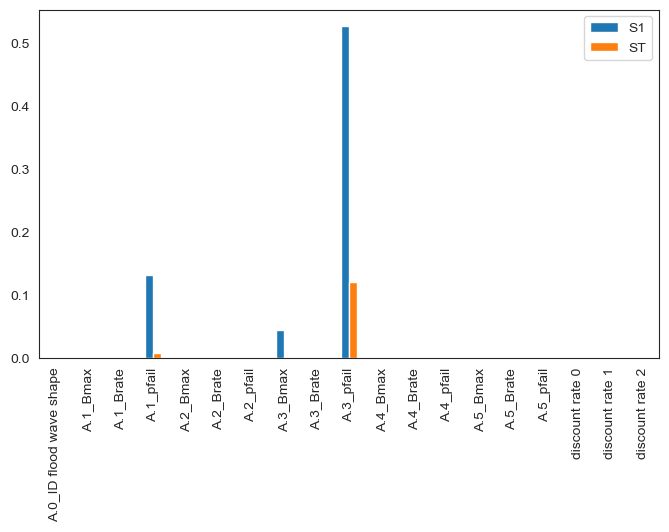

In [17]:
Si_filter = {k:Si[k] for k in ['ST','ST_conf','S1','S1_conf']}
Si_df = pd.DataFrame(Si_filter, index=problem['names'])

sns.set_style('white')
fig, ax = plt.subplots(1)

indices = Si_df[['S1','ST']]
err = Si_df[['S1_conf','ST_conf']]

indices.plot.bar(yerr=err.values.T,ax=ax)
fig.set_size_inches(8,6)
fig.subplots_adjust(bottom=0.3)
plt.show()

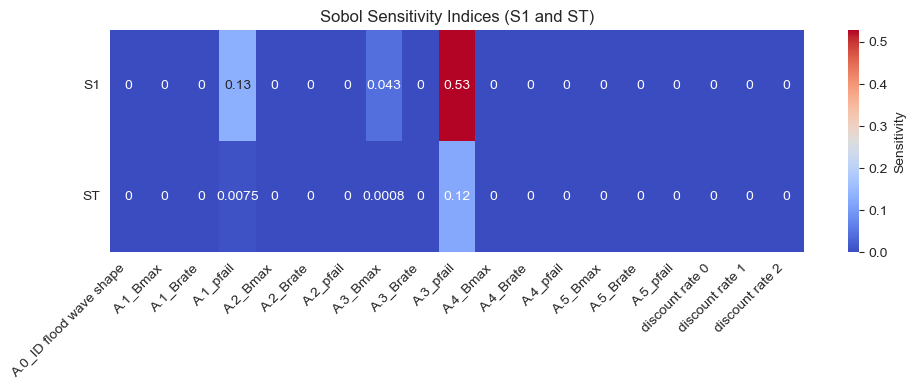

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter just the sensitivity indices (not the confidence intervals)
heatmap_data = Si_df[['S1', 'ST']].T  # Transpose so parameters are columns

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Sensitivity'})
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.title('Sobol Sensitivity Indices (S1 and ST)')
plt.tight_layout()
plt.show()